# Assignment 3

Deadline: 22.04.2026 12:00 CET

- Gallo Alessandro , 25-732-140 , alessandro.gallo2@uzh.ch
- Maruccio Anna , 25-742-800 , anna.maruccio@uzh.ch
- Perbellini Cesare, 25-741-257, cesare.perbellini@uzh.ch
- Venturi Matilde , 25-741-059 , matilde.venturi@uzh.ch

## Prerequisites: Library imports, data load and initialization of the backtest service

In [34]:
# Standard library imports
import os
import sys
import copy
from typing import Optional


# Third party imports
import numpy as np
import pandas as pd

# Add the project root directory to Python path
# Import local modules
project_root = os.path.dirname(os.path.dirname(os.getcwd()))   # Change this path if needed
src_path = os.path.join(project_root, 'qpmwp-course', 'src') #changed for Macbook
sys.path.append(project_root)
sys.path.append(src_path)

# Local modules imports
from helper_functions import (
    # load_pickle,
    load_data_spi,
)
from estimation.covariance import Covariance
from estimation.expected_return import ExpectedReturn
from optimization.constraints import Constraints
from optimization.optimization_data import OptimizationData
from optimization.optimization import (
    Optimization,
    Objective,
    MeanVariance,
)
from backtesting.backtest_item_builder.bib_classes import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
)
from backtesting.backtest_item_builder.bibfn_selection import (
    bibfn_selection_min_volume,
    bibfn_selection_gaps,
)
from backtesting.backtest_item_builder.bibfn_optimization_data import (
    bibfn_return_series,
)
from backtesting.backtest_item_builder.bibfn_constraints import (
    bibfn_budget_constraint,
    bibfn_box_constraints,
    bibfn_size_dependent_upper_bounds,
)
from backtesting.backtest_data import BacktestData
from backtesting.backtest_service import BacktestService
from backtesting.backtest import Backtest



In [35]:
PATH_TO_DATA = '../data_backtesting_assignment3/' # <CHANGE THIS TO YOUR PATH TO DATA> 

In [36]:

# Load market and jkp data from parquet files
import pyarrow.parquet as pq

table_market = pq.read_table(f"{PATH_TO_DATA}market_data.parquet")
table_jkp = pq.read_table(f"{PATH_TO_DATA}jkp_data.parquet")

market_data = table_market.to_pandas(strings_to_categorical=False)
jkp_data = table_jkp.to_pandas(strings_to_categorical=False) #dati per costruire factors 

# -------------------------
# First, ensure that market data and jkp data 
# have the same dates by forward filling the market data for the missing dates.
# -------------------------

market_data_dates = (
    market_data
    .index.get_level_values('date')
    .unique().sort_values()
)
jkp_data_dates = (
    jkp_data
    .index.get_level_values('date')
    .unique().sort_values()
)

# Find the jkp_data_dates which are not in the market_data_dates
missing_dates = jkp_data_dates[~jkp_data_dates.isin(market_data_dates)]

# Extend the market data for the missing dates using the last available market data (i.e., forward fill).
tmp_dict = {}
for date in missing_dates:
    last_date = market_data_dates[market_data_dates <= date][-1]
    tmp_dict[date] = market_data.loc[last_date]
    
df_missing = pd.concat(tmp_dict, axis=0)
df_missing.index.names = market_data.index.names
market_data_ffill = pd.concat([market_data, df_missing]).sort_index()


# -------------------------
# Define rebalancing dates
# -------------------------

n_month = 3 # We want to rebalance every n_month months

# We want to use the dates from the jkp data for rebalancing, 
# since they are less frequent than the market data dates.
rebdates = (
    jkp_data_dates[
        jkp_data_dates > market_data_dates[0]
    ][::n_month]
    .strftime('%Y-%m-%d').tolist()
)
# Drop the first rebalancing dates which are before 2002-01-01, 
# because of poor data coverage.
rebdates = [date for date in rebdates if date > '2002-01-01']


# -------------------------
# Instantiate the BacktestData class
# and set the market, jkp, and benchmark data as attributes
# -------------------------

data = BacktestData()
data.market_data = market_data_ffill  # notice that we use the forward filled market data here
data.jkp_data = jkp_data
data.bm_series = load_data_spi(path='../data/')

In [37]:
# Define the selection item builders.
selection_item_builders = {
    'gaps': SelectionItemBuilder(
        bibfn=bibfn_selection_gaps,
        width=365 * 3,
        n_days=10,
    ),
    'min_volume': SelectionItemBuilder(
        bibfn=bibfn_selection_min_volume,
        width=365 * 3,
        min_volume=500_000,
        agg_fn=np.median,
    ),
}

# Define the optimization item builders.
optimization_item_builders = {
    'return_series': OptimizationItemBuilder(
        bibfn=bibfn_return_series,
        width=365 * 3,
        fill_value=0,
    ),
    'budget_constraint': OptimizationItemBuilder(
        bibfn=bibfn_budget_constraint,
        budget=1
    ),
    'box_constraints': OptimizationItemBuilder(
        bibfn=bibfn_box_constraints,
        upper=0.1
    ),
    'size_dep_upper_bounds': OptimizationItemBuilder(
        bibfn = bibfn_size_dependent_upper_bounds,
        small_cap = {'threshold': 300_000_000, 'upper': 0.02},
        mid_cap = {'threshold': 1_000_000_000, 'upper': 0.05},
        large_cap = {'threshold': 10_000_000_000, 'upper': 0.1},
    ),
}

# Initialize the backtest service
bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

## 1. Maximum Sharpe Ratio Portfolio

a) 

(6 points)

Complete the `MaxSharpe` class below by implementing its methods `set_objective` and `solve`.
The `solve` method should implement an iterative algorithm that quickly approximates the "true" maximimum Sharpe ratio portfolio (given the estimates of mean and covariance). This approximation should be done by repeatedly solving a mean-variance optimization problem, where the risk aversion parameter (which scales the covariance matrix) is adjusted in each iteration. The algorithm should terminate after a maximum of 10 iterations. 

In [38]:
class MaxSharpe(Optimization):

    def __init__(self,
                 constraints: Optional[Constraints] = None,
                 covariance: Optional[Covariance] = None,
                 expected_return: Optional[ExpectedReturn] = None,
                 **kwargs) -> None:
        super().__init__(
            constraints=constraints,
            **kwargs,
        )
        self.covariance = Covariance() if covariance is None else covariance
        self.expected_return = ExpectedReturn() if expected_return is None else expected_return

    def set_objective(self, optimization_data: OptimizationData) -> None:
        X = optimization_data['return_series']
        covmat = self.covariance.estimate(X=X, inplace=False)
        mu = self.expected_return.estimate(X=X, inplace=False)

        self._covmat = covmat
        self._mu = mu

        risk_aversion = self.params.get('risk_aversion', 1.0)
        self.objective = Objective(
            q=-mu,
            P=2 * risk_aversion * covmat,
        )
        return None

    def solve(self) -> None:
        max_iter = self.params.get('max_iter', 10)
        tol = self.params.get('tol', 1e-8)
        risk_aversion = float(self.params.get('risk_aversion', 1.0))

        mu = np.asarray(self._mu, dtype=float).reshape(-1)
        covmat = np.asarray(self._covmat, dtype=float)

        history = []

        for _ in range(max_iter):
            self.objective = Objective(
                q=-mu,
                P=2 * risk_aversion * covmat,
            )

            super().solve()

            w = (
                pd.Series(self.results['weights'])
                .reindex(self.constraints.ids)
                .fillna(0.0)
                .to_numpy(dtype=float)
            )

            port_return = float(mu @ w)
            port_var = float(w @ covmat @ w)

            if port_var <= 0:
                break

            new_risk_aversion = port_return / port_var
            history.append(
                {
                    'risk_aversion': risk_aversion,
                    'expected_return': port_return,
                    'variance': port_var,
                    'sharpe': port_return / np.sqrt(port_var),
                }
            )

            if abs(new_risk_aversion - risk_aversion) <= tol * max(1.0, abs(risk_aversion)):
                risk_aversion = new_risk_aversion
                break

            risk_aversion = new_risk_aversion

        self.params['risk_aversion'] = risk_aversion
        self.results['risk_aversion'] = risk_aversion
        self.results['history'] = pd.DataFrame(history)

        return None

b) 

(2 points)

Provide either a theoretical or an empirical justification that your algorithm converges to the true maximum Sharpe ratio portfolio for the given coefficients of mean and covariance.
Hint: If you want to provide an empirical justification, you can perform an optimization for a single point in time by running the following code.

In [39]:
# bs.optimization = MaxSharpe(
#     covariance=Covariance(method='pearson'),
#     expected_return=ExpectedReturn(method='geometric'),
#     solver_name='cvxopt',  # <change this to your preferred solver>
#     # <optionally add any other arguments you may need, e.g., number of iterations, tolerance, etc.>
# )
# bs.prepare_rebalancing(rebdates[-1])
# bs.optimization.set_objective(bs.optimization_data)
# bs.optimization.solve()

# bs.optimization.results

## 2. Backtest MaxSharpe with Turnover Penalty

(5 points)

The code below runs a backtest of a MaxSharpe portfolio that includes a turnover penalty. The optimization problem is

$$
\arg\min_{w}\;\Bigl(-\mu^\top w \;+\; \frac{\lambda}{2}\, w^\top \Sigma w \;+\; \tau |w - w^{0}|\Bigr),
$$

where $\mu$ is the vector of expected returns, $\Sigma$ the covariance matrix, and $w^{0}$ the initial portfolio weights.
The parameter $\lambda$ is the risk‑aversion coefficient calibrated in Question 1.a, and $\tau$ is the turnover penalty parameter to be calibrated here.

Your task is to choose a value for the turnover penalty such that the MaxSharpe backtest exhibits an annual turnover of approximately 100\%.

**Hint:** run the backtest for only a few rebalancing dates, compute the resulting turnover using method `bt_ms.turnover`, and iteratively adjust the turnover penalty until the target turnover is reached.


In [ ]:
# Calibrate the turnover penalty on a smaller subset of rebalancing dates
subset_rebdates = rebdates[:50]
candidate_penalties = np.geomspace(1e-10, 5e-2, 12)

calibration_results = []

for penalty in candidate_penalties:
    bs_tmp = BacktestService(
        data=data,
        selection_item_builders=copy.deepcopy(selection_item_builders),
        optimization_item_builders=copy.deepcopy(optimization_item_builders),
        rebdates=subset_rebdates,
    )

    bs_tmp.optimization = MaxSharpe(
        covariance=Covariance(method='pearson'),
        expected_return=ExpectedReturn(method='geometric'),
        solver_name='cvxopt',
        turnover_penalty=float(penalty),
        risk_aversion=1.0,
        max_iter=10,
        tol=1e-8,
    )

    bt_tmp = Backtest()
    bt_tmp.run(bs=bs_tmp)

    return_series_tmp = bs_tmp.data.get_return_series(weekdays_only=False)
    to_tmp = bt_tmp.strategy.turnover(return_series=return_series_tmp)

    rebdates_dt = pd.to_datetime(subset_rebdates)
    rebal_per_year = 365.25 / np.median(np.diff(rebdates_dt).astype('timedelta64[D]').astype(int))
    annualized_turnover = to_tmp.iloc[1:].mean() * rebal_per_year

    calibration_results.append(
        {
            'turnover_penalty': float(penalty),
            'annualized_turnover': float(annualized_turnover),
        }
    )

calibration_df = pd.DataFrame(calibration_results)
target_turnover = 1.0
best_penalty = calibration_df.iloc[
    (calibration_df['annualized_turnover'] - target_turnover).abs().argmin()
]['turnover_penalty']

print(calibration_df)
print(f"Chosen turnover_penalty: {best_penalty:.6f}")

# Update the backtest service with the calibrated MaxSharpe optimization object
bs.optimization = MaxSharpe(
    covariance=Covariance(method='pearson'),
    expected_return=ExpectedReturn(method='geometric'),
    solver_name='cvxopt',     # optionally, change this to your preferred solver
    turnover_penalty=float(best_penalty),
    risk_aversion=1.0,
    max_iter=10,
    tol=1e-8,
)

# Instantiate the backtest object
bt_ms = Backtest()

# Run the backtest
bt_ms.run(bs=bs)

Rebalancing date: 2002-01-31
Rebalancing date: 2002-04-30
Rebalancing date: 2002-07-31
Rebalancing date: 2002-10-31
Rebalancing date: 2003-01-31
Rebalancing date: 2003-04-30
Rebalancing date: 2003-07-31
Rebalancing date: 2003-10-31
Rebalancing date: 2004-01-31
Rebalancing date: 2004-04-30
Rebalancing date: 2004-07-31
Rebalancing date: 2004-10-31
Rebalancing date: 2005-01-31
Rebalancing date: 2005-04-30
Rebalancing date: 2005-07-31
Rebalancing date: 2005-10-31
Rebalancing date: 2006-01-31
Rebalancing date: 2006-04-30
Rebalancing date: 2006-07-31
Rebalancing date: 2006-10-31
Rebalancing date: 2007-01-31
Rebalancing date: 2007-04-30
Rebalancing date: 2007-07-31
Rebalancing date: 2007-10-31
Rebalancing date: 2008-01-31
Rebalancing date: 2008-04-30
Rebalancing date: 2008-07-31
Rebalancing date: 2008-10-31
Rebalancing date: 2009-01-31
Rebalancing date: 2009-04-30
Rebalancing date: 2009-07-31
Rebalancing date: 2009-10-31
Rebalancing date: 2010-01-31
Rebalancing date: 2010-04-30
Rebalancing da

## 4. Simulation and Descriptive Statistics

(3 points)

- Simulate the portfolio returns from your MaxSharpe backtest. Use fixed costs of 1% per annum (p.a.) and variable costs of 0.3% p.a.
- Plot the cumulated returns of the MaxSharpe strategy together with those of the SPI Index.
- Plot the turnover of your MaxSharpe strategy over time.
- Print the annualized turnover (computed as the average turnover over the backtest multiplied by the number of rebalancing per year) for your MaxSharpe strategy.
- Create and print a table with descriptive performance statistics for your MaxSharpe strategy and the SPI Index.


/Users/matildeventuri/Desktop/Documents/GitHub/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  portf_ret[0] -= varcost[0]
/Users/matildeventuri/Desktop/Documents/GitHub/qpmwp-course/src/backtesting/strategy.py:195: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  portf_ret[0] -= varcost[0]


<Axes: title={'center': 'Cumulative Performance'}>

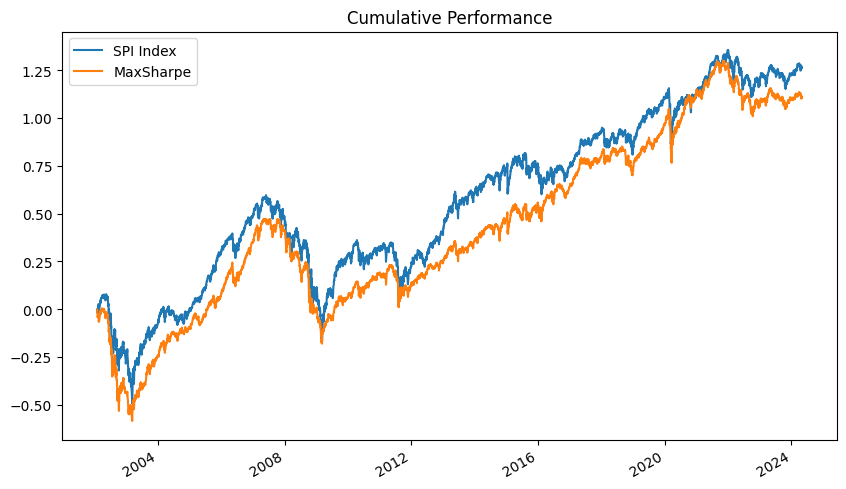

In [41]:
fixed_costs = 0.01
variable_costs = 0.003
return_series = bs.data.get_return_series(weekdays_only=False)

sim_ms = bt_ms.strategy.simulate(
    return_series=return_series,
    fc=fixed_costs,
    vc=variable_costs
)

sim = pd.concat({
    'bm': bs.data.bm_series,
    'ms': sim_ms,
}, axis = 1).dropna()

sim.columns = ['SPI Index', 'MaxSharpe']

# Plot the cumulative returns of the strategy and the benchmark
np.log(1 + sim).cumsum().plot(title='Cumulative Performance', figsize=(10, 6))

<Axes: title={'center': 'Turnover'}>

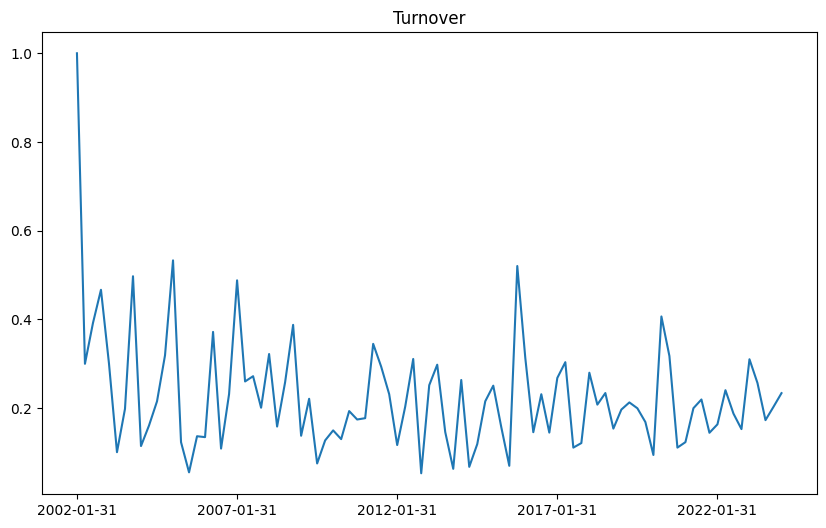

In [42]:
# Turnover
to_ms = bt_ms.strategy.turnover(return_series=return_series)
to_ms.plot(title='Turnover', figsize = (10, 6))

In [43]:
	
# Annualized turnover per annum (pa) in percentage
to_pa =  to_ms.iloc[1:].mean() * rebal_per_year * 100
print(f"The annualized turnover is: {to_pa}%")

The annualized turnover is: 87.00747512286641%


In [44]:
#Descriptive anlysis

